In [29]:
import numpy as np
import scipy.sparse as sp
import time
from dolphindes.cvxopt import DenseSharedProjQCQP, OptimizationHyperparameters

# conda clean --all

In [30]:
# Physical constants
epsilon_0 = 8.854e-12 # F/m
mu_0 = 4e-7 * np.pi # H/m
c = 1/np.sqrt(epsilon_0 * mu_0) # speed of light in vacuum

E0 = 1e3 # plane wave amplitude in V/m

frequency = 2.45e9 # frequency in Hz
wavelength = c / frequency # wavelength in m
print(f"Wavelength: {wavelength} m")

ka = 1 # electrical size of the antenna
k = 2 * np.pi / wavelength # wavenumber
a = ka / k # antenna circumradius
print(f"Antenna circumradius: {a} m")

omega = 2 * np.pi * frequency # angular frequency

conductivity_reduction_factor = 1 # factor to reduce conductivity for testing purposes
copper_conductivity = conductivity_reduction_factor*5.96e7 # S/m
copper_susceptibility = 1j * copper_conductivity / (omega * epsilon_0) # copper susceptance in dimensionless units
print(f"Copper susceptance: {copper_susceptibility:.2e}")

Wavelength: 0.1223655664053944 m
Antenna circumradius: 0.019475084757658086 m
Copper susceptance: 0.00e+00+4.37e+08j


In [31]:
# Calculate surface impedance
delta = np.sqrt(2 / (omega * mu_0 * copper_conductivity)) # skin depth in m
Zs = (1 + 1j) / (copper_conductivity * delta)
# Zs = 1 / (copper_conductivity * delta)
print(f"Surface impedance: {Zs} Ω")

# Load matrices from text files
Lmat = np.loadtxt(r"Lmat_matrix.txt", delimiter=',') # lossy matrix
R0 = np.loadtxt(r"R0_matrix.txt", delimiter=',') # radiated power matrix
X0 = np.loadtxt(r"X0_matrix.txt", delimiter=',') # reactive power matrix
Vinc = E0*np.loadtxt(r"V_vector.txt", delimiter=',') # voltage excitation vector

Urwg = np.loadtxt(r"Urwg_matrix.txt", delimiter=',') # structural modes matrix

Zmat = Zs * Lmat # material impedance matrix
Z0 = R0 + 1j*X0 # free-space impedance matrix
Ztot = Z0 + Zmat # total impedance matrix
Rmat = np.real(Zmat) # rezistivity matrix

Ndes = Lmat.shape[0] # number of design variables
print("Number of design variables: ", Ndes)

Vzero = np.zeros((Ndes,), dtype=complex) # zero vector

Obj = -0.5 * R0
obj = Vzero/2
obj0 = 0

# full plate performance
Ifull = np.linalg.solve(Ztot, Vinc) # current distribution for full plate
Pfull = -np.real(Ifull.conj().T @ Obj @ Ifull) + 2*np.real(Ifull.conj().T @ obj) + obj0 # objective for full plate
print(f"Objective for full plate: {Pfull:.6e} W")

Surface impedance: (0.012739130327240646+0.012739130327240646j) Ω
Number of design variables:  195
Objective for full plate: 1.010821e+01 W


In [32]:
# translate QCQP matrices to Dolphindes notation
Umat = -1j * Ztot.conj() # Dolphindes U matrix
eVec = 1j * Vinc / 2 # Dolphindes e vector
Bmat = Obj # quadratic objective matrix
bVec = obj # linear objective vector
beta = obj0 # constant objective term

In [33]:
# set up optimization variables
Nopt = Umat.shape[0] # number of optimization variables (after reduction)

lags_init = np.zeros((2,))
lags_init[0] = 1

opt_params = OptimizationHyperparameters(opttol=1e-7,                  
    gradConverge=True,           
    min_inner_iter=10,             
    max_restart=10,                
    penalty_ratio=1e-2,           
    penalty_reduction=0.1,        
    break_iter_period=5,          
    verbose=0)


Pdiags = np.column_stack((np.sign(Urwg[:,0]), 1j*np.sign(Urwg[:,0])))
nP = Pdiags.shape[1]
Plist = [sp.diags(Pdiags[:,i]) for i in range(nP)]

for iMode in range(20):
      
    QCQP = DenseSharedProjQCQP(Bmat, bVec, beta,
                            Umat, eVec,
                             Plist, verbose = 1
                                )


    t1 = time.time()

    result = QCQP.solve_current_dual_problem(method = 'bfgs', init_lags = lags_init, opt_params = opt_params)
    print(f"mode: {iMode+1}, bound: {result[0]:.8e}, time: {time.time()-t1}s")
    
    
    # Up = np.sign(Urwg[:,iMode])
    # Up[Up <= 0] = 0
    # Un = np.sign(Urwg[:,iMode])
    # Un[Un >= 0] = 0
    # Plist.append(sp.diags(Up))
    # Plist.append(sp.diags(1j*Up))
    # Plist.append(sp.diags(Un))
    # Plist.append(sp.diags(1j*Un))
    # nP += 4  
    # lags_init = np.zeros((nP,))
    # lags_init[:nP-4] = QCQP.current_lags
    
    
    Plist.append(sp.diags(np.sign(Urwg[:,iMode])))
    Plist.append(sp.diags(1j*np.sign(Urwg[:,iMode])))
    nP += 2  
    lags_init = np.zeros((nP,))
    lags_init[:nP-2] = QCQP.current_lags

Precomputed 2 A matrices and Fs vectors.
mode: 1, bound: 1.01209328e+01, time: 0.3086538314819336s
Precomputed 4 A matrices and Fs vectors.
mode: 2, bound: 1.01209328e+01, time: 0.22785472869873047s
Precomputed 6 A matrices and Fs vectors.
mode: 3, bound: 1.01209327e+01, time: 0.23847579956054688s
Precomputed 8 A matrices and Fs vectors.
mode: 4, bound: 1.01204381e+01, time: 0.39809679985046387s
Precomputed 10 A matrices and Fs vectors.
mode: 5, bound: 1.01204378e+01, time: 0.2786242961883545s
Precomputed 12 A matrices and Fs vectors.
mode: 6, bound: 1.01204164e+01, time: 0.3235743045806885s
Precomputed 14 A matrices and Fs vectors.
mode: 7, bound: 1.01204163e+01, time: 0.34644222259521484s
Precomputed 16 A matrices and Fs vectors.
mode: 8, bound: 1.01204118e+01, time: 0.3763153553009033s
Precomputed 18 A matrices and Fs vectors.
mode: 9, bound: 1.01204115e+01, time: 0.42686939239501953s
Precomputed 20 A matrices and Fs vectors.
mode: 10, bound: 1.01202092e+01, time: 0.6436467170715332

In [34]:
# Now let's check again for PSD of A. We don't expect the constraints to hold or to have strong duality
lags = QCQP.current_lags
totalA = QCQP._get_total_A(lags)
eigenvals, eigenvecs = np.linalg.eig(totalA)
print(f"minimal eigenvalue: {np.min(np.real(eigenvals))}")

minimal eigenvalue: 1.1547472283740966e-07


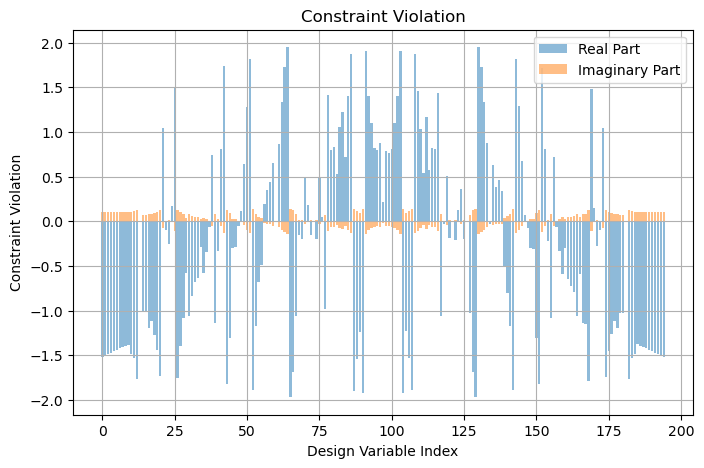

In [35]:
Ivec = QCQP.current_xstar
qLocal= Ivec.conj() * (Umat.conj().T @ Ivec)
lLocal = 2 * Ivec.conj() * eVec
con_violation = 1j*((lLocal - qLocal) / np.abs(0.5*(lLocal + qLocal))).conj() # constraint violation normalized by the magnitude of the constraint value, to get a relative measure of violation. This is more informative than normalizing by lLocal alone, since qLocal can be large and make the violation seem small when it's actually significant.
# plot bar real and imag parts of constraint violation
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.bar(np.arange(Nopt), np.real(con_violation), alpha=0.5, label='Real Part')
plt.bar(np.arange(Nopt), np.imag(con_violation), alpha=0.5, label='Imaginary Part')
plt.xlabel('Design Variable Index')
plt.ylabel('Constraint Violation')
plt.title('Constraint Violation')
plt.legend()
plt.grid(True)
plt.show()

Surface impedance: (0.012739130327240646+0.012739130327240646j) Ω
inference error: 1.2889211028746013


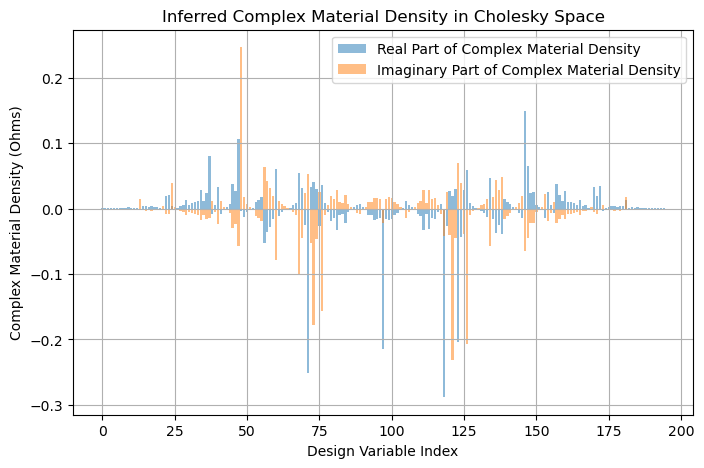

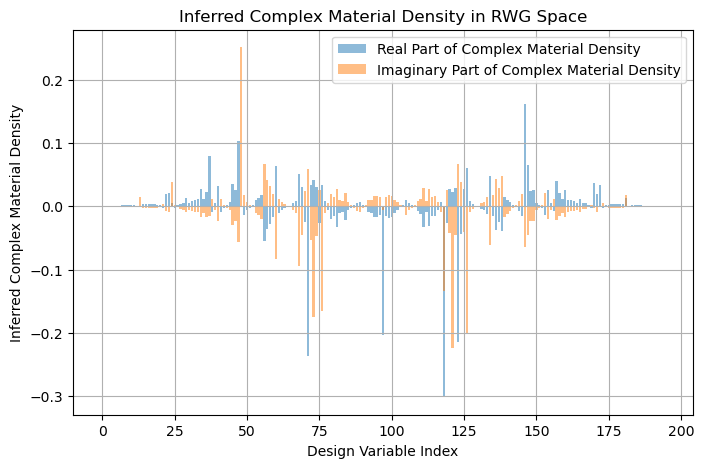

Objective for inferred material density: -1.012020e+01 W


In [36]:
# infer conductivity
Lchol = np.linalg.cholesky(Lmat).conj().T
MfactorInf = np.linalg.inv(Lchol)

# Ivec = np.linalg.solve(Ztot, Vinc) # optimal current distribution in original coordinates

iChol = Lchol @ Ivec
Z0fInf = MfactorInf.conj().T @ Z0 @ MfactorInf
VincfInf = MfactorInf.conj().T @ Vinc

Vopt = Z0fInf @ iChol
Vinf = VincfInf - Vopt
Zinff = Vinf / iChol

# Umd = 1j * np.diag(Pdiags @ lags[0:Pdiags.shape[1]]) @ (Zmatf - np.diag(Zinff)).conj()
# Umds = Umd + Umd.conj().T
# eq4 = (iChol.conj().T @ Umds @ iChol)/(iChol.conj().T @ Zmatf @ iChol)
# print(f"eq4 value normalized by squared norm: {eq4}, expected to be close to zero for consistency with GCD solution")


print(f"Surface impedance: {Zs} Ω")

complexMaterialDensityChol = Zs / Zinff
print(f"inference error: {np.max(np.abs(complexMaterialDensityChol - 1))}")

# bar plot with real and imaginary parts of Zinf for Ndes design variables
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.bar(np.arange(Ndes), np.real(complexMaterialDensityChol), alpha=0.5, label='Real Part of Complex Material Density')
plt.bar(np.arange(Ndes), np.imag(complexMaterialDensityChol), alpha=0.5, label='Imaginary Part of Complex Material Density')
plt.xlabel('Design Variable Index')
plt.ylabel('Complex Material Density (Ohms)')
plt.title('Inferred Complex Material Density in Cholesky Space')
plt.legend()
plt.grid(True)
plt.show()


Zinf = Lchol.conj().T @ np.diag(Zinff) @ Lchol
diagZinf = np.diag(Zinf)
diagZmat = np.diag(Zmat)


complexMaterialDensity = diagZmat / diagZinf

plt.figure(figsize=(8, 5))
plt.bar(np.arange(Ndes), np.real(complexMaterialDensity), alpha=0.5, label='Real Part of Complex Material Density')
plt.bar(np.arange(Ndes), np.imag(complexMaterialDensity), alpha=0.5, label='Imaginary Part of Complex Material Density')
plt.xlabel('Design Variable Index')
plt.ylabel('Inferred Complex Material Density')
plt.title('Inferred Complex Material Density in RWG Space')
plt.legend()
plt.grid(True)
plt.show()

# evaluate performmance for inferred material density
ZtotInf = Z0 + Zinf
IfullInf = np.linalg.solve(ZtotInf, Vinc) # current distribution for inferred material density
PfullInf = np.real(IfullInf.conj().T @ Obj @ IfullInf) # radiated power for inferred material density
print(f"Objective for inferred material density: {PfullInf:.6e} W")


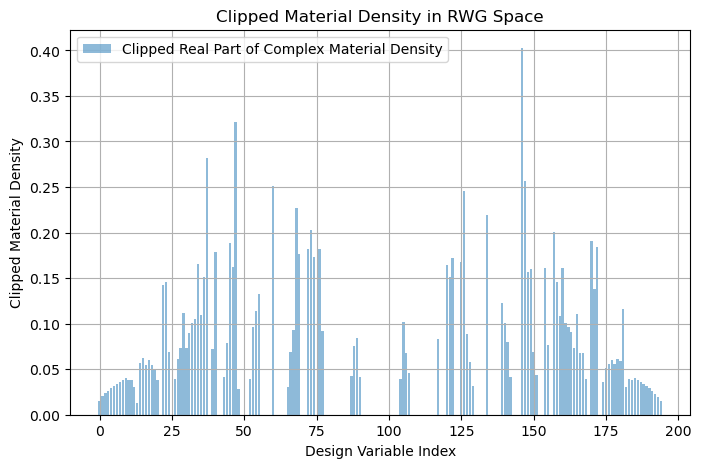

Objective for limited inferred material density: -1.55066113e-05 W


In [37]:
# limit material density to be postive real [0,1]
material_density = np.sqrt(np.clip(np.real(complexMaterialDensity), 1e-9, 1))
plt.figure(figsize=(8, 5))
plt.bar(np.arange(Ndes), material_density, alpha=0.5, label='Clipped Real Part of Complex Material Density')
plt.xlabel('Design Variable Index') 
plt.ylabel('Clipped Material Density')
plt.title('Clipped Material Density in RWG Space')
plt.legend()
plt.grid(True)
plt.show()

addLoss = 1/material_density
ZmatInfLim = np.diag(addLoss) @ Zmat @ np.diag(addLoss)
ZtotInfLim = Z0 + ZmatInfLim
IfullInfLim = np.linalg.solve(ZtotInfLim, Vinc) # current distribution for inferred material density
PfullInfLim = np.real(IfullInfLim.conj().T @ Obj @ IfullInfLim) # radiated power for inferred material density
print(f"Objective for limited inferred material density: {PfullInfLim:.8e} W")